In [1]:
import torch
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import os
from itertools import product
from typing import List, Tuple
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, roc_curve, auc
from torch.amp import GradScaler, autocast  # Set device for GPU usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"CUDA Available: {torch.cuda.is_available()}, Device Name: {torch.cuda.get_device_name() if torch.cuda.is_available() else 'None'}")
print(torch.__version__)  # E.g., 2.4.0+cu118
print(torch.cuda.is_available())  # Should print True
from torch.utils.data import random_split


Using device: cuda
CUDA Available: True, Device Name: NVIDIA GeForce RTX 4060 Laptop GPU
2.5.1
True


# DATA

In [2]:
genuine_extract_path = './content/Offline Genuine'
forgery_extract_path = './content/Offline Forgeries'
class SignatureVerificationDataset(Dataset):
    def __init__(self, genuine_dir, forgery_dir, transform=None):
        """
        Args:
            genuine_dir (str): Path to offline_genuine folder (e.g., './data/offline_genuine').
            forgery_dir (str): Path to offline_forgeries folder (e.g., './data/offline_forgeries').
            transform (callable, optional): Transformations to apply to images.
        """
        self.genuine_dir = genuine_dir
        self.forgery_dir = forgery_dir
        self.transform = transform
        self.pairs = []
        self.labels = []

        # Dictionary to store signatures by author
        genuine_by_author = {}
        forgery_by_author = {}

        # Load genuine signatures
        for filename in os.listdir(genuine_dir):
            if filename.endswith(('.png', '.jpg', '.jpeg','.PNG')):
                try:
                    # Parse filename, e.g., '001_02.png' -> author '001'
                    author_id = filename.split('_')[0]
                    img_path = os.path.join(genuine_dir, filename)
                    if author_id not in genuine_by_author:
                        genuine_by_author[author_id] = []
                    genuine_by_author[author_id].append(img_path)
                except (ValueError, IndexError):
                    print(f"Skipping invalid genuine filename: {filename}")
                    continue

        # Load forged signatures
        for filename in os.listdir(forgery_dir):
            if filename.endswith(('.png', '.jpg', '.jpeg')):
                try:
                    # Parse filename, e.g., '0119001_01.png' -> author '001'
                    parts = filename.split('_')
                    author_id = parts[0][-3:]  # Extract last 3 digits (e.g., '001' from '0119001')
                    img_path = os.path.join(forgery_dir, filename)
                    if author_id not in forgery_by_author:
                        forgery_by_author[author_id] = []
                    forgery_by_author[author_id].append(img_path)
                except (ValueError, IndexError):
                    print(f"Skipping invalid forgery filename: {filename}")
                    continue

        print(f"Genuine authors: {len(genuine_by_author)}, {genuine_by_author.keys()}")
        print(f"Forgery authors: {len(forgery_by_author)}, {forgery_by_author.keys()}")
        for author_id, sigs in genuine_by_author.items():
            print(f"Author {author_id}: {len(sigs)} genuine signatures")
        for author_id, sigs in forgery_by_author.items():
            print(f"Author {author_id}: {len(sigs)} forged signatures")

        # Create pairs for each author
        for author_id in genuine_by_author:
            genuine_sigs = genuine_by_author.get(author_id, [])
            forged_sigs = forgery_by_author.get(author_id, [])
            if not (forged_sigs or genuine_sigs):
                print(f"Warning: No data found for author {author_id}")

            # Genuine-Genuine pairs (label = 1)
            for i in range(len(genuine_sigs)):
                for j in range(i + 1, len(genuine_sigs)):  # Pair different genuine samples
                    self.pairs.append((genuine_sigs[i], genuine_sigs[j]))
                    self.labels.append(1)

            # Genuine-Forgery pairs (label = 0)
            for genuine_sig in genuine_sigs:
                for forged_sig in forged_sigs:
                    self.pairs.append((genuine_sig, forged_sig))
                    self.labels.append(0)

        print(f"Training Total pairs: {len(self.pairs)}, Total labels: {len(self.labels)}")
        print(f"Training Positive pairs (label=1): {sum(1 for label in self.labels if label == 1)}")
        print(f"Training Negative pairs (label=0): {sum(1 for label in self.labels if label == 0)}")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        # Get pair of image paths and label
        img1_path, img2_path = self.pairs[idx]
        label = self.labels[idx]

        # Load images
        img1 = Image.open(img1_path).convert('L')  # Grayscale, like FashionMNIST
        img2 = Image.open(img2_path).convert('L')

        # Apply transforms
        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)


        return img1, img2, label

# Example usage
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize to match FashionMNIST if needed
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Standard normalization
])

dataset = SignatureVerificationDataset(
    genuine_dir=genuine_extract_path,
    forgery_dir=forgery_extract_path,
    transform=transform
)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)

Genuine authors: 10, dict_keys(['001', '002', '003', '004', '006', '009', '012', '014', '015', '016'])
Forgery authors: 10, dict_keys(['014', '004', '015', '016', '002', '006', '012', '009', '001', '003'])
Author 001: 24 genuine signatures
Author 002: 24 genuine signatures
Author 003: 24 genuine signatures
Author 004: 24 genuine signatures
Author 006: 24 genuine signatures
Author 009: 24 genuine signatures
Author 012: 24 genuine signatures
Author 014: 24 genuine signatures
Author 015: 24 genuine signatures
Author 016: 23 genuine signatures
Author 014: 16 forged signatures
Author 004: 11 forged signatures
Author 015: 12 forged signatures
Author 016: 16 forged signatures
Author 002: 12 forged signatures
Author 006: 12 forged signatures
Author 012: 12 forged signatures
Author 009: 12 forged signatures
Author 001: 8 forged signatures
Author 003: 12 forged signatures
Training Total pairs: 5673, Total labels: 5673
Training Positive pairs (label=1): 2737
Training Negative pairs (label=0): 293

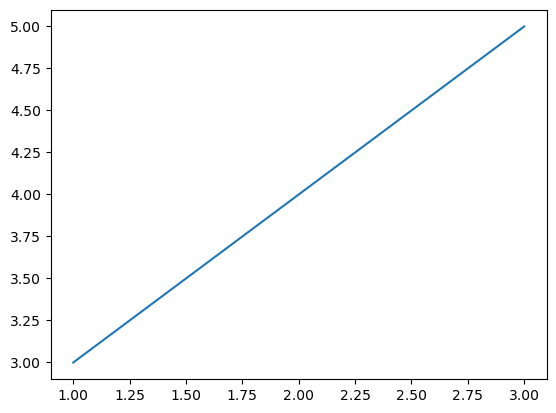

In [3]:
plt.close('all')  # Close all open figuresos.makedirs('saved_models', exist_ok=True)
plt.plot([1,2,3],[3,4,5])

In [4]:
reference_extract_path='./content/Reference(646)'
ques_extract_path = './content/Questioned(1287)'
class SignatureVerificationTestDataset(Dataset):
    def __init__(self, reference_dir, ques_dir, transform=None):
        """
        Args:
            reference_dir (str): Path to offline_genuine folder (e.g., './data/offline_genuine').
            ques_dir (str): Path to offline_forgeries folder (e.g., './data/offline_forgeries').
            transform (callable, optional): Transformations to apply to images.
        """
        self.reference_dir = reference_dir
        self.ques_dir = ques_dir
        self.transform = transform
        self.pairs = []
        self.labels = []

        # Dictionary to store signatures by author
        reference_by_author = {}
        ques_genuine_by_author = {}
        ques_forgery_by_author = {}

        # Load reference signatures
        for author_id in os.listdir(reference_dir):
            for filename in os.listdir(os.path.join(reference_dir,author_id)):
                if filename.endswith(('.png', '.jpg', '.jpeg','.PNG')):
                    try:
                        # Parse filename, e.g., '001_02.png' -> author '001'
                        img_path = os.path.join(reference_dir,author_id, filename)
                        if author_id not in reference_by_author:
                            reference_by_author[author_id] = []
                        reference_by_author[author_id].append(img_path)
                    except (ValueError, IndexError):
                        print(f"Skipping invalid genuine filename: {filename}")
                        continue
        # Load questioned genuine signatures
        for author_id in os.listdir(ques_dir):
            for filename in os.listdir(os.path.join(ques_dir,author_id)):
                if filename.endswith(('.png', '.jpg', '.jpeg')):
                    try:
                        # Parse filename, e.g., '001_02.png' -> author '001'
                        img_path = os.path.join(ques_dir,author_id, filename)
                        if author_id not in ques_genuine_by_author:
                            ques_genuine_by_author[author_id] = []
                        ques_genuine_by_author[author_id].append(img_path)
                    except (ValueError, IndexError):
                        print(f"Skipping invalid genuine filename: {filename}")
                        continue

        # Load questioned forgery signatures
        for author_id in os.listdir(ques_dir):
            for filename in os.listdir(os.path.join(ques_dir,author_id)):
                if filename.endswith(('.PNG')):
                    try:
                        # Parse filename, e.g., '001_02.png' -> author '001'
                        img_path = os.path.join(ques_dir,author_id, filename)
                        if author_id not in ques_forgery_by_author:
                            ques_forgery_by_author[author_id] = []
                        ques_forgery_by_author[author_id].append(img_path)
                    except (ValueError, IndexError):
                        print(f"Skipping invalid genuine filename: {filename}")
                        continue

        # Create pairs for each author
        for author_id in reference_by_author:
            reference_sigs = reference_by_author.get(author_id, [])
            ques_genuine_sigs= ques_genuine_by_author.get(author_id,[])
            ques_forged_sigs = ques_forgery_by_author.get(author_id, [])
            if not (reference_sigs or ques_forgery_by_author or ques_genuine_by_author):
                print(f"Warning: No data found for author {author_id}")

            # Reference-Genuine pairs (label = 1)
            for i in range(len(reference_sigs)):
                for j in range(len(ques_genuine_sigs)):  # Pair different genuine samples
                    self.pairs.append((reference_sigs[i], ques_genuine_sigs[j]))
                    self.labels.append(1)

            # Reference-Forgery pairs (label = 0)
            for i in range(len(reference_sigs)):
                for j in range(len(ques_forged_sigs)):  # Pair different genuine samples
                    self.pairs.append((reference_sigs[i], ques_forged_sigs[j]))
                    self.labels.append(0)

        print(f"Training Total pairs: {len(self.pairs)}, Total labels: {len(self.labels)}")
        print(f"Training Positive pairs (label=1): {sum(1 for label in self.labels if label == 1)}")
        print(f"Training Negative pairs (label=0): {sum(1 for label in self.labels if label == 0)}")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        # Get pair of image paths and label
        img1_path, img2_path = self.pairs[idx]
        label = self.labels[idx]

        # Load images
        img1 = Image.open(img1_path).convert('L')  # Grayscale, like FashionMNIST
        img2 = Image.open(img2_path).convert('L')

        # Apply transforms
        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        label = torch.tensor(label, dtype=torch.float32)

        return img1, img2, label

# Example usage
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize to match FashionMNIST if needed
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Standard normalization
])

testdataset = SignatureVerificationTestDataset(
    reference_extract_path,
    ques_extract_path,
    transform=transform
)

test_size = int(0.8 * len(testdataset))
val_size = len(testdataset) - test_size

test_dataset, val_dataset = random_split(testdataset,[test_size,val_size])

val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)

testdataloader = DataLoader(
    test_dataset,
    batch_size=64,  # Reduced for laptop GPU
    shuffle=True,
    num_workers=0,  # Adjusted for performance (set to 0 for debugging)
    pin_memory=True
)

Training Total pairs: 15392, Total labels: 15392
Training Positive pairs (label=1): 7752
Training Negative pairs (label=0): 7640


In [5]:
class SiameseCNN(nn.Module):
    def __init__(self):
        super(SiameseCNN, self).__init__()
        self.cnn =nn.Sequential(
        nn.Conv2d(1, 32, 3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),
    
        nn.Conv2d(32, 64, 3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),
    
        nn.Conv2d(64, 128, 3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2),
    
        nn.Flatten(),
        nn.Linear(128 * 32 * 32, 256),
        nn.ReLU(),
        nn.Dropout(0.6),
        nn.Linear(256, 64)
)

    def forward(self, x1, x2):
        embedding1 = self.cnn(x1)
        embedding2 = self.cnn(x2)
        return embedding1, embedding2

In [6]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, emb1, emb2, label):
        cosine_sim = nn.functional.cosine_similarity(emb1, emb2)
        loss = label * (1 - cosine_sim) + (1 - label) * torch.clamp(cosine_sim - self.margin, min=0)
        return loss.mean()
    


In [7]:
torch.cuda.empty_cache()
x = torch.randn(32, 1, 256, 256).to(device)
y = torch.randn(32, 1, 256, 256).to(device)
out1, out2 = model(x, y)
print(out1.device, out2.device)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Current CUDA device (GPU):", torch.cuda.current_device())
    print("GPU name (NVIDIA):", torch.cuda.get_device_name(0))
    print("CUDA compute capability:", torch.cuda.get_device_capability(0))
else:
    print("No NVIDIA GPU detected → PyTorch is using CPU")

# Detect Intel GPU (oneAPI / iGPU) – only if you have intel-extension-for-pytorch installed
try:
    import intel_extension_for_pytorch as ipex
    if torch.xpu.is_available():                     # ← Intel GPU
        print("Intel GPU (XPU) detected!")
        print("Intel GPU name:", torch.xpu.get_device_name(0))
    else:
        print("No Intel GPU detected")
except:
    print("Intel Extension for PyTorch not installed → cannot detect Intel GPU")

# Apple Silicon (M1/M2/M3/M4) – Metal Performance Shaders
if torch.backends.mps.is_available():
    print("Apple Silicon GPU (MPS) detected and active")
else:
    print("No Apple Silicon GPU active")

print("\nFinal device PyTorch is actually using right now:")
print("Device of model parameters:", next(model.parameters()).device)


NameError: name 'model' is not defined

In [8]:
torch.cuda.empty_cache()


In [9]:
# Training with mixed precision
plt.close('all')  # Close all open figuresos.makedirs('saved_models', exist_ok=True)
margin=0.8
lr=0.01
torch.cuda.empty_cache()

model = SiameseCNN().to(device)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)  # Use multiple GPUs if available
criterion = ContrastiveLoss(margin=margin)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scaler = GradScaler()
num_epochs = 15
epoch_losses = []


for epoch in range(num_epochs):
    model.train()
    batch_losses = []
    for img1, img2, labels in dataloader:
        img1, img2, labels = img1.to(device, non_blocking=True), img2.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with autocast("cuda"):
            emb1, emb2 = model(img1, img2)
            loss = criterion(emb1, emb2, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        batch_losses.append(loss.item())
    
    avg_loss = sum(batch_losses) / len(batch_losses)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}")

# Plot training loss curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o', label=f"m={margin}, lr={lr}")
plt.xlabel('Epoch')
plt.ylabel('Contrastive Loss')
plt.title(f'Loss Curve (margin={margin}, lr={lr})')
plt.legend()
plt.grid(True)
plt.show()
# plt.savefig(f'second_saved_models/saved_models/LENET/loss_margin_LENET_256size{margin}_lr{lr}.png')

torch.cuda.empty_cache()  # Clears GPU cache in PyTorch
model.eval()
correct = 0
total = 0
cosine_sim_all = []
labels_all = []

with torch.no_grad():
    for img1, img2, labels in val_loader:
        img1 = img1.to(device, non_blocking=True)
        img2 = img2.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        try:
            with autocast("cuda"):
                emb1, emb2 = model(img1, img2)
                emb1 = F.normalize(emb1, p=2, dim=1)
                emb2 = F.normalize(emb2, p=2, dim=1)
                cosine_sim = F.cosine_similarity(emb1, emb2)
            cosine_sim_all.append(cosine_sim)
            labels_all.append(labels)
            predictions = (cosine_sim > threshold).float()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
        except RuntimeError as e:
            print(f"Error in evaluation: {e}")
            if "out of memory" in str(e):
                torch.cuda.empty_cache()
                continue

cosine_sim_all = torch.cat(cosine_sim_all)
labels_all = torch.cat(labels_all)

# Histogram
indices = np.random.permutation(total)[:1000]
cosine_sim_np = cosine_sim_all[indices].cpu().numpy()
labels_np = labels_all[indices].cpu().numpy()
cosine_sim_genuine = cosine_sim_np[labels_np == 1].tolist()
cosine_sim_forged = cosine_sim_np[labels_np == 0].tolist()

plt.figure(figsize=(8, 6))
sns.histplot(cosine_sim_genuine, color='blue', label='Genuine Pairs', kde=True, stat='density')
sns.histplot(cosine_sim_forged, color='red', label='Forged Pairs', kde=True, stat='density')
plt.axvline(x=threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel('Cosine Similarity')
plt.ylabel('Density')
plt.title(f'Cosine Similarity Distribution (Threshold={threshold}, Margin={margin}, LR={lr})')
plt.legend()
plt.grid(True)
# plt.savefig(f"second_saved_models/saved_models/LENET/cosine_sim/cosine_similarity_distribution_threshold_{threshold}_{margin}_{lr}.png")
plt.show()  # Display the plot
plt.close()

accuracy = correct / total if total > 0 else 0.0
precision, recall, f1, _ = precision_recall_fscore_support(labels_all.cpu(), predictions.cpu(), average='binary')
print(f"Threshold: {threshold}, Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}")


model_path = f"second_saved_models/saved_models/LENET/siamese_margin{margin}256size0.6dropout_lr{lr}.pt"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

Epoch 1/15, Average Loss: 0.1001
Epoch 2/15, Average Loss: 0.0581
Epoch 3/15, Average Loss: 0.0150
Epoch 4/15, Average Loss: 0.0047


KeyboardInterrupt: 

In [ ]:
# # Load the model
# model = SiameseCNN().to(device)
# try:
#     model.load_state_dict(torch.load(PATH, map_location=device))
# except RuntimeError as e:
#     print(f"Error loading model: {e}")


In [ ]:
genuine_count = 0
forged_count = 0
total_samples = 0
for img1, img2, labels in dataloader:
    genuine_count += (labels == 1).sum().item()
    forged_count += (labels == 0).sum().item()
    total_samples += labels.size(0)
print(f"Genuine: {genuine_count} ({genuine_count / total_samples * 100:.2f}%), Forged: {forged_count} ({forged_count / total_samples * 100:.2f}%)")

In [ ]:
def evaluate_accuracy(model, testdataloader, margin, lr, threshold=0.5, device="cuda"):
    torch.cuda.empty_cache()  # Clears GPU cache in PyTorch
    model.eval()
    correct = 0
    total = 0
    cosine_sim_all = []
    labels_all = []
    
    with torch.no_grad():
        for img1, img2, labels in testdataloader:
            img1 = img1.to(device, non_blocking=True)
            img2 = img2.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            try:
                with autocast():
                    emb1, emb2 = model(img1, img2)
                    emb1 = F.normalize(emb1, p=2, dim=1)
                    emb2 = F.normalize(emb2, p=2, dim=1)
                    cosine_sim = F.cosine_similarity(emb1, emb2)
                cosine_sim_all.append(cosine_sim)
                labels_all.append(labels)
                predictions = (cosine_sim > threshold).float()
                correct += (predictions == labels).sum().item()
                total += labels.size(0)
            except RuntimeError as e:
                print(f"Error in evaluation: {e}")
                if "out of memory" in str(e):
                    torch.cuda.empty_cache()
                    continue

    cosine_sim_all = torch.cat(cosine_sim_all)
    labels_all = torch.cat(labels_all)

    # Histogram
    indices = np.random.permutation(total)[:1000]
    cosine_sim_np = cosine_sim_all[indices].cpu().numpy()
    labels_np = labels_all[indices].cpu().numpy()
    cosine_sim_genuine = cosine_sim_np[labels_np == 1].tolist()
    cosine_sim_forged = cosine_sim_np[labels_np == 0].tolist()

    plt.figure(figsize=(8, 6))
    sns.histplot(cosine_sim_genuine, color='blue', label='Genuine Pairs', kde=True, stat='density')
    sns.histplot(cosine_sim_forged, color='red', label='Forged Pairs', kde=True, stat='density')
    plt.axvline(x=threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Density')
    plt.title(f'Cosine Similarity Distribution (Threshold={threshold}, Margin={margin}, LR={lr})')
    plt.legend()
    plt.grid(True)
    plt.savefig(f"saved_models/LENET/cosine_similarity_distribution_threshold_{threshold}_{margin}_{lr}.png")
    plt.show()  # Display the plot
    plt.close()

    # Confusion Matrix
    predictions = (cosine_sim_all > threshold).float()
    cm = confusion_matrix(labels_all.cpu(), predictions.cpu())
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Forged', 'Genuine'], yticklabels=['Forged', 'Genuine'])
    plt.title(f'Confusion Matrix (Threshold={threshold}, Margin={margin}, LR={lr})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(f"saved_models/LENET/confusion_matrix_threshold_{threshold}_{margin}_{lr}.png")
    plt.show()  # Display the plot
    plt.close()

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels_all.cpu(), cosine_sim_all.cpu())
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (Threshold={threshold}, Margin={margin}, LR={lr})')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.savefig(f"saved_models/LENET/roc_curve_threshold_{threshold}_{margin}_{lr}.png")
    plt.show()  # Display the plot
    plt.close()

    # Metrics
    accuracy = correct / total if total > 0 else 0.0
    precision, recall, f1, _ = precision_recall_fscore_support(labels_all.cpu(), predictions.cpu(), average='binary')
    print(f"Threshold: {threshold}, Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}")
    
    return accuracy

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SiameseCNN().to(device)  # Initialize model outside the loop
thresholds = [0.93]

# Load and evaluate models
for filename in os.listdir('./saved_models/LENET/'):
    if filename.endswith('.pt'):
        PATH = os.path.join('./saved_models/LENET', filename)
        parts = filename.split('_')
        margin = parts[1]  # e.g., 'margin0.5'
        lr = parts[2].replace('.pt', '')  # e.g., 'lr0.001'
        print(f"Attempting to load model: {filename}")
        print(margin,lr)
        if(margin=='margin0.8size256' and lr=="lr0.005"):
            try:
                model.load_state_dict(torch.load(PATH, map_location=device))
                print(f"Successfully loaded model from {PATH}")
                for thresh in thresholds:
                    accuracy = evaluate_accuracy(model, testdataloader, margin, lr, threshold=thresh, device=device)
                    print(f"Model: {filename}, Threshold: {thresh}, Accuracy: {accuracy:.4f}")
            except Exception as e:
                print(f"Error loading model {filename}: {e}")